# CA3: CA Groups 11
## Indra Bdr Adhikari, Zarar Zafar, and Syed Muhammad Murtaza Zaidi

Binary classification task to predict coffee bean quality (good vs. defective) based on sensory grading features.

### Imports

- Load libraries for data handling and numerical operations  
- Load libraries for visualising feature distributions  
- Load preprocessing tools for imputing missing values and scaling features  
- Load utilities for pipelines and stratified train/validation splits  
- Load classifiers for model training  
- Load accuracy metric for evaluation

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns 

In [524]:
# Additional
from sklearn import datasets
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier


from sklearn.neighbors import KNeighborsClassifier


from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.compose import make_column_selector as selector


### Reading data

- Load the dataset into a dataframe  
- Inspect the number of rows and columns  
- Display the first rows to confirm correct loading  
- Check column names and data types

In [101]:
# Load the test data
test = pd.read_csv("test.csv")
print(test.shape)
test.head(1)

(215, 7)


,ID,aroma,acidity,body,uniformity,clean_cup,sweetness
0,740,7.5,7.25,7.5,10.0,10.0,10.0


In [19]:
# Load the train data
df = pd.read_csv("train.csv")
print(df.info())
df.head(1)

<class 'pandas.DataFrame'>
RangeIndex: 856 entries, 0 to 855
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          856 non-null    int64  
 1   aroma       856 non-null    float64
 2   acidity     856 non-null    float64
 3   body        856 non-null    float64
 4   uniformity  856 non-null    float64
 5   clean_cup   856 non-null    float64
 6   sweetness   856 non-null    float64
 7   Quality     856 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 53.6 KB
None


,ID,aroma,acidity,body,uniformity,clean_cup,sweetness,Quality
0,587,7.75,7.5,7.5,10.0,10.0,10.0,1


### Data exploration and visualisation

- Examine data types of all features  
- Visualise numeric feature distributions using histograms  
- Analyse correlations between numeric features using a heatmap  
- Identify value ranges and potential outliers

In [22]:
print(df.isnull().sum())

ID            0
aroma         0
acidity       0
body          0
uniformity    0
clean_cup     0
sweetness     0
Quality       0
dtype: int64


In [35]:
df.describe()

,ID,aroma,acidity,body,uniformity,clean_cup,sweetness,Quality
count,856.000000,856.000000,856.000000,856.000000,856.000000,856.000000,856.000000,856.000000
mean,535.713785,7.577850,7.543937,7.526612,9.839918,9.827804,9.868645,0.542056
std,308.100821,0.312419,0.328159,0.316273,0.486250,0.790329,0.568554,0.498519
min,1.000000,6.170000,5.250000,5.170000,6.000000,0.000000,1.330000,0.000000
25%,266.750000,7.420000,7.330000,7.330000,10.000000,10.000000,10.000000,0.000000
50%,535.500000,7.580000,7.580000,7.500000,10.000000,10.000000,10.000000,1.000000
75%,807.250000,7.750000,7.750000,7.750000,10.000000,10.000000,10.000000,1.000000
max,1070.000000,8.670000,8.750000,8.580000,10.000000,10.000000,10.000000,1.000000


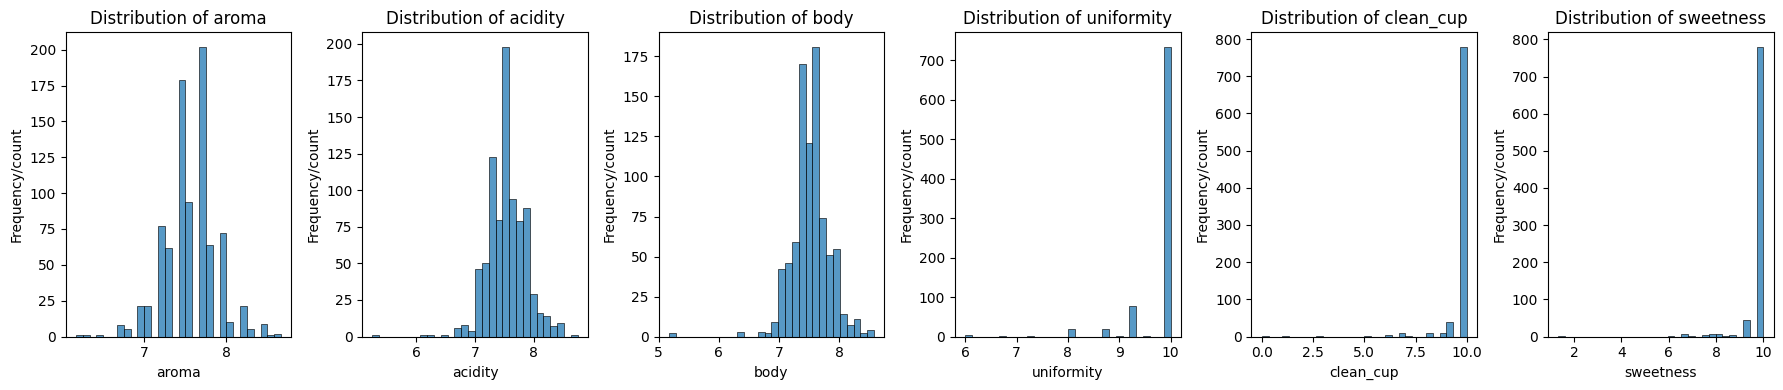

In [301]:
features = df.columns.drop("ID").drop("Quality")

fig, axes = plt.subplots(1, len(features), figsize=(18, 4))

for i, feature in enumerate(features):
    sns.histplot(df[feature], bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency/count')

plt.tight_layout()
plt.show()

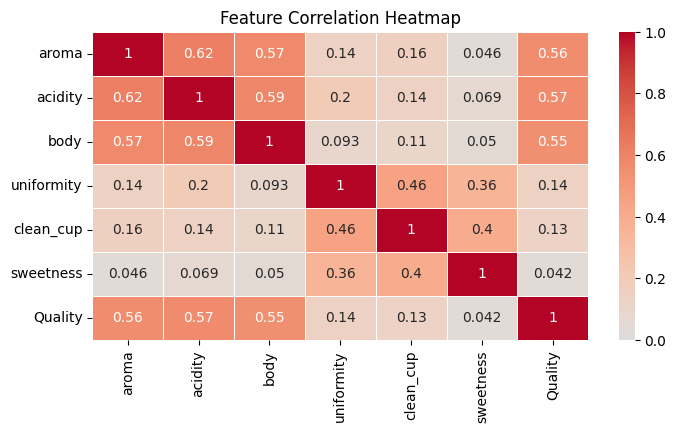

In [138]:
# Calculate the correlation matrix for numeric columns only and except "ID" columns
corr_matrix = df.drop(columns=["ID"]).select_dtypes(include=['number']).corr()

plt.figure(figsize=(8, 4))

# Draw the heatmap
sns.heatmap(corr_matrix, 
            annot=True,      
            cmap='coolwarm',
            vmin=0, vmax=1, 
            center=0,        # Ensure 0 is the neutral color 
            linewidths=0.5)  # Add small gaps

plt.title("Feature Correlation Heatmap")
plt.show()

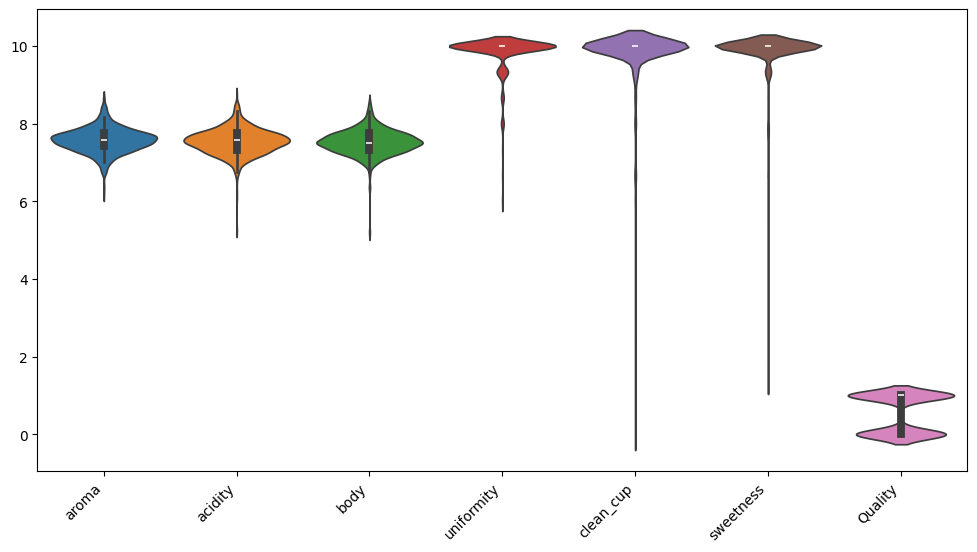

In [151]:
# Identify value ranges and potential outliers
cols=df.drop(columns=["ID"]).columns

fig, ax = plt.subplots(1, 1, figsize=(12, 6))  

data = pd.DataFrame(df, columns=cols)  

sns.violinplot(data=data, ax=ax)
plt.xticks(rotation=45, ha='right')
plt.show()

### Data cleaning
 
- Remove duplicates
- Standardise column names
- Convert feature columns to numeric
- Verify class balance

In [288]:
# Duplicates with columns ID
df.duplicated().sum()

0

In [571]:
# Duplicates without columns ID
df.drop(columns=["ID"]).duplicated().sum()

168

In [573]:
# Creating new df without columns ID
new_df = df.drop(columns=["ID"])
new_df.shape

(856, 7)

In [575]:
new_df.duplicated().sum()

168

In [576]:
# Removed duplicates
new_df.drop_duplicates(inplace=True)
new_df.shape

(688, 7)

In [551]:
new_df.columns.tolist()

['aroma', 'acidity', 'body', 'uniformity', 'clean_cup', 'sweetness', 'Quality']

In [578]:
# Standardise column names
new_df.columns = new_df.columns.str.lower()
new_df.columns.tolist()

['aroma', 'acidity', 'body', 'uniformity', 'clean_cup', 'sweetness', 'quality']

In [579]:
# checking features data type
new_df[features].dtypes

aroma         float64
acidity       float64
body          float64
uniformity    float64
clean_cup     float64
sweetness     float64
dtype: object

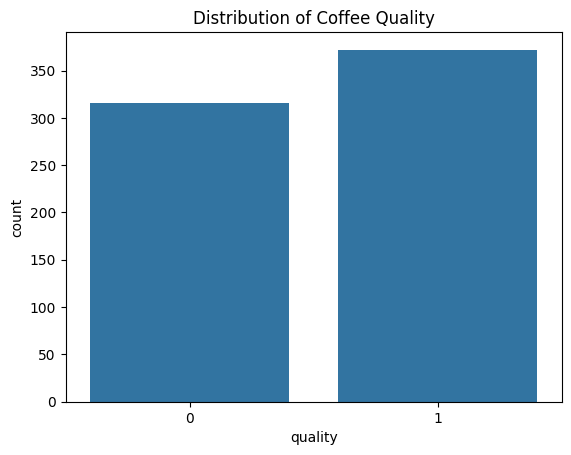

In [580]:
#verify class balance
sns.countplot(x='quality', data=new_df)
plt.title('Distribution of Coffee Quality')
plt.show()

### Data preprocessing

- Separate features and target variable  
- Select numeric features for modelling  
- Identify columns to exclude
- Check for missing values in the feature matrix  
- Prepare a feature list for the preprocessing pipeline

In [581]:
# Separate features and target variable  
features = features
target = "quality"

In [582]:
# Checking corrilation of new df
new_df.corr() 

,aroma,acidity,body,uniformity,clean_cup,sweetness,quality
aroma,1.000000,0.615505,0.567028,0.148328,0.168256,0.046152,0.547318
acidity,0.615505,1.000000,0.582333,0.203005,0.139115,0.068760,0.559909
body,0.567028,0.582333,1.000000,0.095983,0.111638,0.051566,0.537543
uniformity,0.148328,0.203005,0.095983,1.000000,0.448285,0.345876,0.159031
clean_cup,0.168256,0.139115,0.111638,0.448285,1.000000,0.396436,0.147641
sweetness,0.046152,0.068760,0.051566,0.345876,0.396436,1.000000,0.046580
quality,0.547318,0.559909,0.537543,0.159031,0.147641,0.046580,1.000000


### Columns to exclude:
- **ID**; It has nothing to do with quality of the coffee (Which is already excluded in `new_df`.)
- **sweetness**; It only have corrilation `0.0466` with quality, so it can be exclude.


In [583]:
new_df = new_df.drop(columns="sweetness")
new_df.head(1)

,aroma,acidity,body,uniformity,clean_cup,quality
0,7.75,7.5,7.5,10.0,10.0,1


In [584]:
# Checking for missing values in the feature matrix and target
new_features = features[0:5]

X = new_df[new_features]
y = new_df[target]

print(X.isnull().sum())
y.isnull().sum()

aroma         0
acidity       0
body          0
uniformity    0
clean_cup     0
dtype: int64


0

Feature ranking (descending importance):
 1) 0.3513 body
 2) 0.3307 acidity
 3) 0.2516 aroma
 4) 0.0380 uniformity
 5) 0.0283 clean_cup


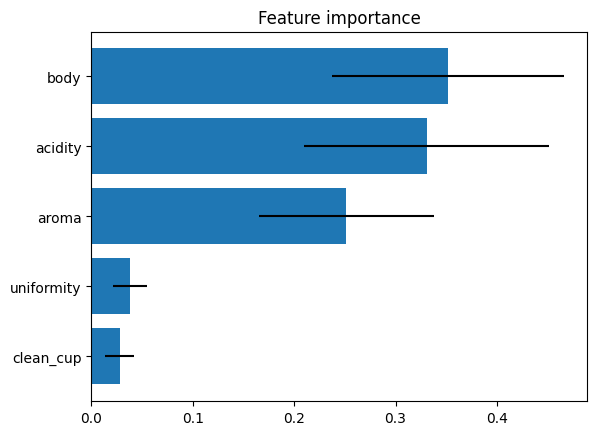

In [585]:
# Source; from lecture 12, to use the random forrest for features selection.

# Split the data into a training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a random forest classifier
clf = RandomForestClassifier(n_estimators=500, random_state=42)
clf.fit(X_train, y_train)

# Print the feature ranking as a list
print("Feature ranking (descending importance):")
ranking = { features[i]: clf.feature_importances_[i] for i in range(X.shape[1]) }
feature_name_max_length = max(ranking.keys(), key=len)
for i, feature in enumerate(sorted(ranking, key=ranking.get, reverse=True)):
    print(f"{i+1:2d}) {ranking[feature]:.4f} {feature}")

# Plot the feature importances of the forest
# Feature names on the y-axis, importances on the x-axis
# The most important features are at the top
# This means we first have to sort the features
feature_importance = clf.feature_importances_
indices = np.argsort(feature_importance)

plt.figure()
plt.title("Feature importance")
plt.yticks(range(X.shape[1]), np.array(features)[indices])

# Add error bars as well by computing the standard deviation of the feature importances
std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)
plt.barh(range(X.shape[1]), feature_importance[indices], xerr=std[indices], align="center")

plt.show()

### Modelling

- Define a preprocessing pipeline with imputation and scaling  
- Perform repeated stratified train/validation splits  
- Train KNN, Logistic Regression, and SVM etc. with multiple hyperparameters  
- Compare the mean validation accuracy across models  
- Select the best-performing model and parameter combination

In [586]:
# Split into training and test data

# Print lables of all classes in data set
print("Class labels:", np.unique(y))

# Split data into training and test data (70% training, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)


# Show distribution of classes in input data, training data and test data
print(f"Labels counts in y: {np.bincount(y)}")
print(f"Labels counts in y_train: {np.bincount(y_train)}")
print(f"Labels counts in y_test: {np.bincount(y_test)}")

Class labels: [0 1]
Labels counts in y: [316 372]
Labels counts in y_train: [221 260]
Labels counts in y_test: [ 95 112]


In [587]:
# creating pipeline

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # missing with Median
    ('scaler', StandardScaler()) # scale the numbers                          
])

# applying to the features
X_train_processed = numeric_transformer.fit_transform(X_train) # medians and z-score parameters
X_test_processed = numeric_transformer.transform(X_test) # consistent transformation without data leakage 

In [589]:
## KNN

## Default KNN
knn = KNeighborsClassifier()  # Default k=5
knn.fit(X_train_processed, y_train)
y_pred = knn.predict(X_test_processed)
accuracy = accuracy_score(y_pred, y_test)
print(f"Default 5-NN accuracy on test set: {accuracy:.3f}")

# Optimize k using 50 random train-validation splits
best_k = 0
best_accuracy = 0

for k in range(1, 50):
    accuracies = []
    for r in range(100):  # 100 different splits
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_train_processed, y_train, 
            test_size=0.3, random_state=r  
        )
        knn = KNeighborsClassifier(n_neighbors=k)
        y_pred = knn.fit(X_tr, y_tr).predict(X_val)  # validation
        accuracies.append(accuracy_score(y_pred, y_val))

    accuracy = np.mean(accuracies)  # average 

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_k = k

print(f"Best k: {best_k}, Best accuracy during optimization: {best_accuracy:.3f}")

# Train best model on full training set
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_processed, y_train)  # full training set

# Final evaluation on test set
y_pred_final = best_knn.predict(X_test_processed)
accuracy = accuracy_score(y_pred_final, y_test)
print(f"Final accuracy of {best_k}-NN on the test set: {accuracy:.3f}")

Default 5-NN accuracy on test set: 0.816
Best k: 40, Best accuracy during optimization: 0.821
Final accuracy of 40-NN on the test set: 0.845


In [425]:
# Perceptron

## Default Perceptron
perceptron = Perceptron()  # Default parameters
perceptron.fit(X_train_processed, y_train)
y_pred = perceptron.predict(X_test_processed)
accuracy = accuracy_score(y_pred, y_test)
print(f"Default Perceptron accuracy on test set: {accuracy:.3f}")

# Optimize Perceptron hyperparameters using 100 random train-validation splits
best_params = {}
best_accuracy = 0

# Parameters to try
max_iter_options = [100, 500, 1000]
eta_options = [0.0001, 0.001, 0.01, 0.1, 1.0]  # learning rate
penalty_options = [None, 'l1', 'l2', 'elasticnet']

for max_iter in max_iter_options:
    for eta in eta_options:
        for penalty in penalty_options:
            accuracies = []
            for r in range(100):  # 100 random splits
                X_tr, X_val, y_tr, y_val = train_test_split(
                    X_train_processed, y_train,
                    test_size=0.4, random_state=r
                )
                perceptron = Perceptron(
                    max_iter=max_iter,
                    eta0=eta,
                    penalty=penalty,
                    random_state=r
                )
                y_pred = perceptron.fit(X_tr, y_tr).predict(X_val)
                accuracies.append(accuracy_score(y_pred, y_val))

            accuracy = np.mean(accuracies)  # mean over 100 splits

            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {
                    'max_iter': max_iter,
                    'eta0': eta,
                    'penalty': penalty
                }

print(f"Best Parameters: {best_params}")
print(f"Best accuracy during optimization: {best_accuracy:.3f}")

# Train best model on full training set
best_perceptron = Perceptron(
    max_iter=best_params['max_iter'],
    eta0=best_params['eta0'],
    penalty=best_params['penalty'],
    random_state=1
)
best_perceptron.fit(X_train_processed, y_train)

# Final evaluation on test set (only once!)
y_pred_final = best_perceptron.predict(X_test_processed)
accuracy = accuracy_score(y_pred_final, y_test)
print(f"Final Perceptron accuracy on test set: {accuracy:.3f}")

Default Perceptron accuracy on test set: 0.792
Best Parameters: {'max_iter': 100, 'eta0': 0.01, 'penalty': 'l2'}
Best accuracy during optimization: 0.758
Final Perceptron accuracy on test set: 0.763


In [547]:
## Default Logistic Regression
clf = LogisticRegression()
clf.fit(X_train_processed, y_train)
y_pred = clf.predict(X_test_processed)
test_accuracy = accuracy_score(y_test, y_pred)
train_accuracy = clf.score(X_train_processed, y_train)
print(f"Default LR Training Accuracy: {train_accuracy:.2%}")
print(f"Default LR Test Accuracy:     {test_accuracy:.2%}")

# Optimize LR hyperparameters
best_params = {}
best_accuracy = 0

# Parameters to try
C_options        = np.arange(-8, 10, 1.0)
penalty_options  = ['l1', 'l2', None]
max_iter_options = [100, 500, 1000]

for C in C_options:
    for penalty in penalty_options:
        for max_iter in max_iter_options:
            try:
                clf = LogisticRegression(
                    C=C,
                    penalty=penalty,
                    max_iter=max_iter
                )
                #  5-fold cross validation on training set only!
                # https://scikit-learn.org/stable/modules/cross_validation.html
                scores = cross_val_score(
                    clf, 
                    X_train_processed, y_train, 
                    cv=5  # 5 different splits automatically!
                )
                accuracy = np.mean(scores)  # mean of 5 folds
            except:
                continue

            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {'C': C, 'penalty': penalty, 'max_iter': max_iter}

print(f"Best Parameters: {best_params}")
print(f"Best accuracy during optimization: {best_accuracy:.2%}")

# Train best model on full training set
best_clf = LogisticRegression(
    C=best_params['C'],
    penalty=best_params['penalty'],
    max_iter=best_params['max_iter'],
)
best_clf.fit(X_train_processed, y_train)

# Final evaluation on test set (only once!)
y_pred_final = best_clf.predict(X_test_processed)
test_accuracy  = accuracy_score(y_test, y_pred_final)
train_accuracy = best_clf.score(X_train_processed, y_train)
print(f"\nFinal LR Training Accuracy: {train_accuracy:.2%}")
print(f"Final LR Test Accuracy:     {test_accuracy:.2%}")

Default LR Training Accuracy: 82.54%
Default LR Test Accuracy:     85.02%
Best Parameters: {'C': 1.0, 'penalty': 'l2', 'max_iter': 100}
Best accuracy during optimization: 82.53%

Final LR Training Accuracy: 82.54%
Final LR Test Accuracy:     85.02%


In [567]:
# SVC

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

## Default SVM
svm = SVC()
svm.fit(X_train_processed, y_train)
y_pred = svm.predict(X_test_processed)
test_accuracy = accuracy_score(y_test, y_pred)
train_accuracy = svm.score(X_train_processed, y_train)
print(f"Default SVM Training Accuracy: {train_accuracy:.2%}")
print(f"Default SVM Test Accuracy:     {test_accuracy:.2%}")

# Optimize SVM hyperparameters using GridSearchCV
param_grid = [
    # Linear kernel
    {
        'kernel': ['linear'],
        'C':      [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
    },
    # RBF kernel (most popular)
    {
        'kernel': ['rbf'],
        'C':      [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        'gamma':  ['scale', 'auto', 0.001, 0.01, 0.1, 1.0]
    },
    # Polynomial kernel
    {
        'kernel': ['poly'],
        'C':      [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        'degree': [2, 3, 4],            # polynomial degree
        'gamma':  ['scale', 'auto']
    },
    # Sigmoid kernel
    {
        'kernel': ['sigmoid'],
        'C':      [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        'gamma':  ['scale', 'auto']
    }
]

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
grid_search = GridSearchCV(
    SVC(random_state=1),
    param_grid,
    cv=5,               # 5-fold cross validation
    scoring='accuracy',
    n_jobs=-1,          # use all CPU cores
    verbose=1           # shows progress
)
grid_search.fit(X_train_processed, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.2%}")

# Final evaluation on test set
best_svm = grid_search.best_estimator_  # automatically gets best model
y_pred_final = best_svm.predict(X_test_processed)
test_accuracy  = accuracy_score(y_test, y_pred_final)
train_accuracy = best_svm.score(X_train_processed, y_train)
print(f"\nFinal SVM Training Accuracy: {train_accuracy:.2%}")
print(f"Final SVM Test Accuracy:     {test_accuracy:.2%}")

Default SVM Training Accuracy: 85.31%
Default SVM Test Accuracy:     86.38%
Fitting 5 folds for each of 90 candidates, totalling 450 fits



Best Parameters: {'C': 1.0, 'kernel': 'linear'}
Best CV Accuracy: 83.96%

Final SVM Training Accuracy: 84.31%
Final SVM Test Accuracy:     85.21%


In [566]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize and train using ALL features
# max_iter=1000 to ensure the math "converges"
clf = LogisticRegression()
clf.fit(X_train_processed, y_train)

# Predict on the test set
y_pred = clf.predict(X_test_processed)

# Calculate Accuracy
# This compares your predictions to the actual labels (y_test)
test_accuracy = accuracy_score(y_test, y_pred)
train_accuracy = clf.score(X_train_processed, y_train)

print(f"Training Accuracy: {train_accuracy:.2%}")
print(f"Test Accuracy: {test_accuracy:.2%}")

Training Accuracy: 84.14%
Test Accuracy: 85.21%


In [590]:
df_test = pd.read_csv("test.csv")

# Extract IDs and Features
test_ids = df_test['ID']
X_real_test = df_test[new_features]

# Preprocess using same transformer
X_real_test_processed = numeric_transformer.transform(X_real_test)

#  Predict classes)

y_final = best_knn.predict(X_real_test_processed)

submission = pd.DataFrame({
    "ID": df_test["ID"],
    "Quality": y_final
})

submission = submission.sort_values(by="ID")

submission.to_csv("submission.csv", index=False)

print("Submission with probabilities created!")

Submission with probabilities created!


### Final evaluation

- Train the selected model on the full training dataset  
- Apply the same preprocessing steps to the test data  
- Generate predictions using the final model  
- Prepare outputs for performance reporting and submission

### Kaggle submission